In [1]:
import matplotlib.pyplot as plt
import numpy as np
from gvxrPython3 import gvxr, twins

In [2]:
twin = twins.createDigitalTwin(name="DTHE")
gvxr.createOpenGLContext()

Mon Oct 20 21:53:19 2025 ---- Create window (ID: -1)
Mon Oct 20 21:53:19 2025 ---- Request an interactive OpenGL context
Mon Oct 20 21:53:19 2025 ---- Initialise GLFW
Mon Oct 20 21:53:19 2025 ---- Create an OpenGL window with a 4.3 context.
Mon Oct 20 21:53:19 2025 ---- Make the window's context current
Mon Oct 20 21:53:19 2025 ---- Initialise GLEW
Mon Oct 20 21:53:19 2025 ---- OpenGL vendor: NVIDIA Corporation
Mon Oct 20 21:53:19 2025 ---- OpenGL renderer: NVIDIA GeForce RTX 4070 Ti SUPER/PCIe/SSE2
Mon Oct 20 21:53:19 2025 ---- OpenGL version: 4.3.0 NVIDIA 570.133.07
Mon Oct 20 21:53:19 2025 ---- Use OpenGL 4.5.
Mon Oct 20 21:53:19 2025 ---- Use OpenGL Compute Shader.
Mon Oct 20 21:53:19 2025 ---- Initialise the X-ray renderer if needed and if possible


In [3]:
mesh_path = "./data/models/Industrial-Part.stl"
# mesh_path = None
gvxr.removePolygonMeshesFromSceneGraph()
if mesh_path is not None:
    mesh_label = "part"
    gvxr.loadMeshFile(mesh_label, str(mesh_path), "mm")


    # Use AL for now, and optimise composition later
    gvxr.setElement(mesh_label, "Al")
    gvxr.setDensity(mesh_label, 2.78, "g/cm3")

    # Center mesh
    gvxr.moveToCenter(mesh_label)
    gvxr.applyCurrentLocalTransformation(mesh_label)

Mon Oct 20 21:53:19 2025 ---- file_name:	./data/models/Industrial-Part.stl	nb_faces:	3932	nb_vertices:	11796	bounding_box (in cm):	(-7.8, -0.5, -0.8)	(4.6, 0.5, 1.7)


In [4]:
twin.beam.kev = 160
twin.beam.ua = 200

exposure = twin.specification.detector.exposures[3]

twin.detector.exposure = exposure
twin.detector.gain = 6
twin.detector.fov = 3

sdd = 807.248
twin.sod = 306.414
twin.odd = sdd - twin.sod
print(twin)

Selected Beam: X-ray 2
Beam Settings: keV: 160, ua: 200, filters: [], position: (x:0.0mm, y:0.0mm, z:306.414mm)

Detector:
Detector Settings: exposure: 0.167, fov: 3, gain: 6, position: (x:0.0mm, y:0.0mm, z:500.83400000000006mm)

Stage:
SOD: 306.414
SDD: 807.248
ODD: {self.odd}



In [5]:
print("\n - ".join(str(twin.specification.detector).split(", "))) # noqa: T201
print("\n - ".join(str(twin.specification.beams[twin.selected_beam]).split(", "))) # noqa: T201
print(twin.specification.stage) # noqa: T201

Detector: 2880x2880 (+7 more)
 - @ 150.0um pixels
 - 6 exposures
 - Lsf: Yes
 - Scintillator: Gd2O2S DRZ-Plus 210.0mm
 - Gains: Calibrated k with 7 ADUs
Tube beam: 60kV - 260kV
 - 50uA - 500uA (302.33uA @ 260kV @ 500uA)
 - Calibrated Flux: True (53301.55 photons per cm2 @ 1mAs @ 860.0mm)
 - shape: POINT
 - internal_filters: [['Al'
 - 0.5]]
 - filters: []
TwinStage(source=XYZRange(x=(0, 0, None), y=(0, 0, None), z=(0, 1000, None)), detector=XYZRange(x=(0, 0, None), y=(0, 0, None), z=(0, 1000, None)), static_sdd=False)


In [6]:
twin.apply()

Mon Oct 20 21:53:19 2025 ---- Initialise the renderer with 32 bits per floating-point numbers in GPU memory


(2880, 1440)
1.0
0.09061013217451663


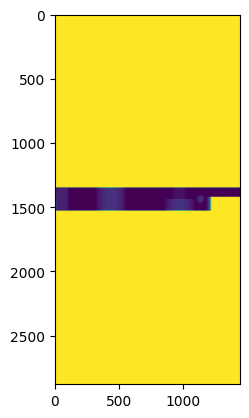

In [7]:
xray = np.asarray(gvxr.computeXRayImage()) / gvxr.getWhiteImage()

plt.imshow(xray)
print(xray.shape)
print(xray.max())
print(xray.min())